# TP 2 - Exercice 2

**Prénom et nom : Hamadou BA**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## Exercice 2 - Régression linéaire multivariée et écriture matriciellle de la méthode de descente du gradient

Dans ce problème, on utilise des données correspondant à 47 exemples d'apprentissage sur des données immobilières à Portland, Oregon (USA). Les données d'entrée $x$ (stockées dans le ficheir `ex2x.dat`) correspondent aux surfaces et au nombre de pièces de ces 47 appartements et la donnée cible $y$ (stockée dans le fichier `ex2y.dat`) correspond au prix de ces mêmes appartements.

1. Utiliser la fonction `loadtxt`du package `numpy`en Python (ici désigné par `np`). Cette fonction permet de lire les fichiers et de les concertir en vecteurs/matrices :
```
    x=np.loadtxt('ex2x.dat');
    y=np.loadtxt('ex2y.dat');
``` 

In [2]:
x = np.loadtxt('ex2x.dat')
y = np.loadtxt('ex2y.dat')
m = len(y)
print('x :', x.shape, ' y :', y.shape)
print('5 premiers logements (surface, pièces) -> prix :')
for xi, yi in zip(x[:5], y[:5]):
    print('   ', xi, '->', yi)

x : (47, 2)  y : (47,)
5 premiers logements (surface, pièces) -> prix :
    [2104.    3.] -> 399900.0
    [1600.    3.] -> 329900.0
    [2400.    3.] -> 369000.0
    [1416.    2.] -> 232000.0
    [3000.    4.] -> 539900.0


**Réponse :** $x$ est une matrice $47\times2$ (colonne 1 : surface, colonne 2 : nombre de pièces) et $y$ un vecteur de 47 prix.

2. Prétraitement des données : utiliser la fonction `sklearn.preprocessing.StandardScaler` pour normaliser les données.

In [3]:
print('avant normalisation : moyennes =', x.mean(axis=0), ' écarts-types =', x.std(axis=0))

scaler = StandardScaler()           # normalisation "centrage-réduction"
x_norm = scaler.fit_transform(x)
print('après normalisation : moyennes =', x_norm.mean(axis=0).round(10), ' écarts-types =', x_norm.std(axis=0))

# matrice augmentée X (colonne de 1 pour theta0) et vecteur cible Y
X = np.hstack([np.ones((m, 1)), x_norm])
Y = y.reshape(-1, 1)
print('X :', X.shape, ' Y :', Y.shape)

avant normalisation : moyennes = [2000.68085106    3.17021277]  écarts-types = [7.86202619e+02 7.52842809e-01]
après normalisation : moyennes = [-0.  0.]  écarts-types = [1. 1.]
X : (47, 3)  Y : (47, 1)


**Réponse :** `StandardScaler` applique la normalisation « centrage-réduction » du cours : $\overline{X_{ij}}=\dfrac{X_{ij}-\mu(X_i)}{\sigma(X_i)}$. Chaque colonne a alors une moyenne nulle et un écart-type égal à 1.

C'est indispensable ici : la surface vaut environ 2000 alors que le nombre de pièces vaut environ 3. Sans normalisation, les deux paramètres ont des échelles très différentes et la descente de gradient converge très mal (ou diverge pour $\alpha=0{,}07$).

On construit ensuite la matrice augmentée $X=[I_1\ \ X_1\ \ X_2]$ (colonne de 1 en premier) et le vecteur colonne $Y$.

3. Définir les fonctions en Python sous forme matricielle pour représenter la fonction hypothèse $h_\theta (X)$, le vecteur tel que défini dans le cours :$E = h_\theta (X) - Y$, la fonction décrivant une itération et la fonction de coût $J(\theta)$.

In [4]:
def h(theta, X):
    """Hypothèse sous forme matricielle : h_theta(X) = X theta"""
    return X @ theta

def E(theta, X, Y):
    """Vecteur des écarts : E = h_theta(X) - Y"""
    return h(theta, X) - Y

def J(theta, X, Y):
    """Fonction de coût : J(theta) = 1/(2m) E^t E"""
    e = E(theta, X, Y)
    return (e.T @ e).item() / (2 * len(Y))

def iteration(theta, alpha, X, Y):
    """Une itération : theta* = theta - alpha/m X^t E"""
    return theta - alpha / len(Y) * X.T @ E(theta, X, Y)

theta = np.zeros((3, 1))
print('J(0) =', J(theta, X, Y))

J(0) = 65591548106.45744


**Réponse :** en notation matricielle (cours, §6.7) :
- hypothèse : $h_\theta(X)=X\theta$ ;
- écarts : $E=h_\theta(X)-Y$ ;
- coût : $J(\theta)=\dfrac{1}{2m}E^tE$ ;
- itération : $\theta^*=\theta-\dfrac{\alpha}{m}X^tE$.

Ces formules regroupent en un seul produit matriciel les $n+1$ formules de mise à jour $\theta_j^*=\theta_j-\frac{\alpha}{m}\sum_i(h_\theta(x_i)-y_i)x_{ij}$.

4. Pour la valeur du taux d'apprentissage $\alpha=0,07$, effectuer le calcul de régression permettant d'obtenir le vecteur $\theta = (\theta_0, \theta_1, \theta_2)$ optimal permettant de calculer la meilleure régression linéaire multivariée sur le jeu de données d'apprentissage.

In [5]:
eps = 1e-10   # même critère d'arrêt que dans l'exercice 1

def descente(alpha, eps=eps, max_iter=100000):
    """Itère depuis theta = 0 jusqu'à |J(theta*) - J(theta)| / J(theta) < eps"""
    theta = np.zeros((X.shape[1], 1))
    hist = [J(theta, X, Y)]
    for _ in range(max_iter):
        theta = iteration(theta, alpha, X, Y)
        hist.append(J(theta, X, Y))
        if abs((hist[-1] - hist[-2]) / hist[-2]) < eps:
            break
    return theta, len(hist) - 1, hist

theta, n_iter, hist = descente(0.07)
print("nombre d'itérations :", n_iter)
print('theta =', theta.ravel().round(2))
print(f'J(theta) = {J(theta, X, Y):.4e}')

nombre d'itérations : 320
theta = [340412.66 109445.19  -6575.75]
J(theta) = 2.0433e+09


**Réponse :** avec $\alpha=0{,}07$ et le critère $10^{-10}$, la descente s'arrête après **320 itérations** avec $\theta\approx(340\,413 ;\ 109\,445 ;\ -6\,576)$.

Comme les données sont normalisées, $\theta_0$ correspond au prix d'un logement « moyen » (surface et nombre de pièces moyens), $\theta_1$ à l'effet d'un écart-type de surface et $\theta_2$ à l'effet d'un écart-type de nombre de pièces. On compare ce résultat à la solution exacte à la question 5.

5. Nous allons maintenant automatiser la recherche du meilleur taux d'apprentissage $\alpha \in [0,001 ; 10]$. Pour ce faire, on devra calculer pour chaque itération la valeur de la fonction de coût $J(\theta)$ et on stockera toutes ces valeurs dans un vecteur. Comme on veut sélectionner un taux d'apprentissage efficace, on va comparer les résultats de calcul de $J(\theta)$ sur 50 itérations en changenat de taux d'apprentissage à chaque série d'itérations. Les valeurs de ce taux doivent rester dans l'intervalle initialement donné $\alpha \in [0,001 ; 10]$. On tracera alors les courbes représentant en abscisse, le nombre d'itérations et en ordonnées les valeurs de la fonction de coût ; chaque courbe correspond à une valeur du taux d'apprentissage. A partir de ces courbes, sélectionner ce qui parît être le meilleur taux d'apprentissage et recalculer le vecteur $\theta$ jusqu'à la convergence. Utiliser ce vecteur $\theta$ pour prédire le prix d'un logement de 1650 m2 et de 3 pièces. 

alpha = 0.001   J après 50 itérations = 5.9415e+10
alpha = 0.003   J après 50 itérations = 4.8827e+10
alpha = 0.01    J après 50 itérations = 2.5061e+10
alpha = 0.03    J après 50 itérations = 5.2248e+09
alpha = 0.1     J après 50 itérations = 2.0613e+09
alpha = 0.3     J après 50 itérations = 2.0433e+09
alpha = 1       J après 50 itérations = 2.0433e+09
alpha = 3       J après 50 itérations = 1.5822e+66
alpha = 10      J après 50 itérations = 1.1219e+126


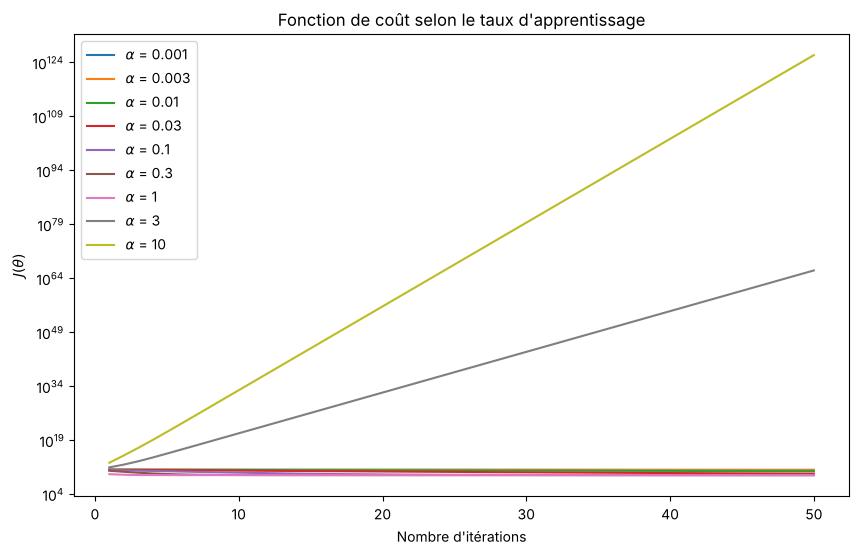

In [6]:
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]   # valeurs dans [0,001 ; 10]
n_it = 50

plt.figure(figsize=(10, 6))
for a in alphas:
    theta_a = np.zeros((3, 1))
    J_hist = np.zeros(n_it)                 # vecteur des valeurs de J
    for k in range(n_it):
        theta_a = iteration(theta_a, a, X, Y)
        J_hist[k] = J(theta_a, X, Y)
    print(f'alpha = {a:<6}  J après 50 itérations = {J_hist[-1]:.4e}')
    plt.plot(range(1, n_it + 1), J_hist, label=f'$\\alpha$ = {a}')
plt.yscale('log')
plt.xlabel("Nombre d'itérations"); plt.ylabel('$J(\\theta)$')
plt.title("Fonction de coût selon le taux d'apprentissage")
plt.legend(); plt.show()

Pour mieux distinguer les taux qui convergent, on retire les deux valeurs qui divergent :

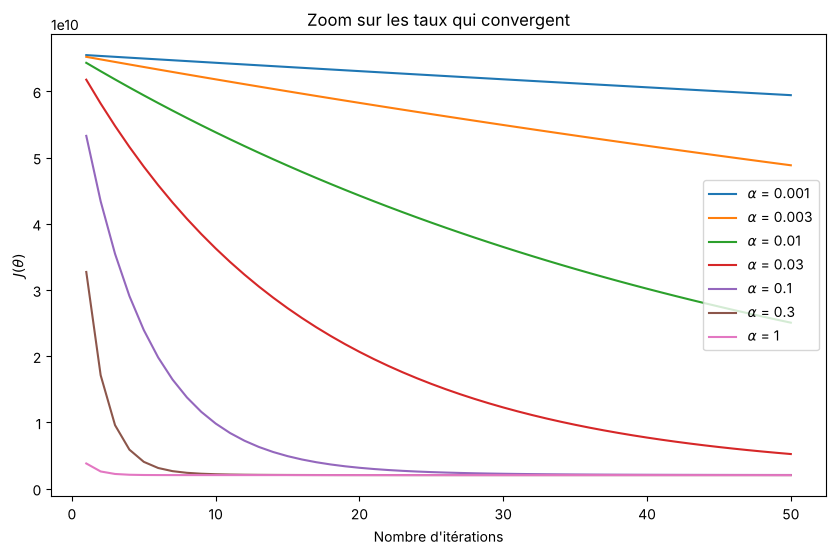

In [7]:
plt.figure(figsize=(10, 6))
for a in [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]:
    theta_a = np.zeros((3, 1)); J_hist = np.zeros(n_it)
    for k in range(n_it):
        theta_a = iteration(theta_a, a, X, Y)
        J_hist[k] = J(theta_a, X, Y)
    plt.plot(range(1, n_it + 1), J_hist, label=f'$\\alpha$ = {a}')
plt.xlabel("Nombre d'itérations"); plt.ylabel('$J(\\theta)$')
plt.title('Zoom sur les taux qui convergent')
plt.legend(); plt.show()

**Réponse :** lecture des courbes :
- $\alpha\in\{0{,}001 ;\ 0{,}003 ;\ 0{,}01\}$ : $J$ décroît trop lentement, on est encore loin du minimum après 50 itérations ;
- $\alpha\in\{0{,}03 ;\ 0{,}1\}$ : convergence correcte mais encore lente ;
- $\alpha\in\{0{,}3 ;\ 1\}$ : $J$ atteint son minimum en quelques itérations seulement ;
- $\alpha\in\{3 ;\ 10\}$ : le pas est trop grand, on « rate » le minimum et $J$ **diverge** (après 50 itérations il atteint $10^{66}$ et $10^{126}$).

Le meilleur taux d'apprentissage est donc **$\alpha=1$** : c'est la décroissance la plus rapide sans divergence (avec le critère $10^{-10}$, $\alpha=1$ converge en 22 itérations contre 77 pour $\alpha=0{,}3$ et 227 pour $\alpha=0{,}1$). On recalcule $\theta$ jusqu'à la convergence avec cette valeur :

In [8]:
alpha_opt = 1
theta_opt, n_opt, _ = descente(alpha_opt)
print("nombre d'itérations :", n_opt)
print('theta =', theta_opt.ravel().round(2))
print(f'J(theta) = {J(theta_opt, X, Y):.4e}')

# vérification : solution exacte des moindres carrés (équations normales X^t X theta = X^t Y)
theta_exact = np.linalg.solve(X.T @ X, X.T @ Y)
print('solution exacte :', theta_exact.ravel().round(2))

nombre d'itérations : 22
theta = [340412.66 109447.48  -6578.34]
J(theta) = 2.0433e+09
solution exacte : [340412.66 109447.8   -6578.35]


**Réponse :** avec $\alpha=1$, le critère $10^{-10}$ est atteint en **22 itérations** (contre 320 avec $\alpha=0{,}07$) et on obtient $\theta\approx(340\,413 ;\ 109\,447 ;\ -6\,578)$, quasiment identique à la solution exacte des moindres carrés $(340\,413 ;\ 109\,448 ;\ -6\,578)$ (écart relatif inférieur à $10^{-5}$). Le bon choix de $\alpha$ divise donc le nombre d'itérations par environ 15.

Le coefficient $\theta_2$ négatif s'explique par la forte corrélation entre surface et nombre de pièces : à surface égale, un logement découpé en plus de pièces ne vaut pas plus cher.

**Prédiction.** Le nouveau logement doit subir **la même normalisation** que les données d'apprentissage : on utilise `scaler.transform` (et non `fit_transform`, qui recalculerait moyenne et écart-type), puis on ajoute le 1 correspondant à $\theta_0$.

In [9]:
nouveau = np.array([[1650, 3]])                       # surface 1650, 3 pièces
nouveau_norm = scaler.transform(nouveau)              # même normalisation que l'apprentissage
x_nouveau = np.hstack([np.ones((1, 1)), nouveau_norm])
prix = h(theta_opt, x_nouveau).item()
print('logement normalisé :', nouveau_norm.round(4))
print(f'prix prédit : {prix:,.0f}'.replace(',', ' '))
print(f'(avec la solution exacte : {h(theta_exact, x_nouveau).item():,.0f})'.replace(',', ' '))

logement normalisé : [[-0.446  -0.2261]]
prix prédit : 293 082
(avec la solution exacte : 293 081)


**Réponse :** le prix prédit pour un logement de 1650 m2 et 3 pièces est d'environ **293 000** (293 082 avec le $\theta$ obtenu par descente de gradient, 293 081 avec la solution exacte).

*Remarque :* dans ce jeu de données (Portland), les surfaces sont en réalité exprimées en pieds carrés (ft²) ; on garde l'unité de l'énoncé, le calcul est identique.